In [17]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import class_weight

#import tensorflow_datasets as tfds

In [2]:
path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [3]:
# Sourced directly from TruckerPath
park_data_1 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_1 - Copy.csv")
park_data_2 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_2 - Copy.csv")
park_data_3 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_3 - Copy.csv")
park_data = pd.concat([park_data_1, park_data_2, park_data_3], ignore_index=True)

In [4]:
truck_stop = pd.read_excel("output_excel\Model_Stops_V3.xlsx")

In [5]:
avail_park = park_data[park_data["pin id"].isin(truck_stop["pin id"].unique())].copy()

In [6]:
avail_park["time(utc)"] = pd.to_datetime(avail_park["time(utc)"])

In [89]:
avail_park["day_of_week"] = avail_park["time(utc)"].dt.dayofweek
avail_park["day_name"] = avail_park["time(utc)"].dt.day_name()
avail_park["hour"] = avail_park["time(utc)"].dt.hour
avail_park["month"] = avail_park["time(utc)"].dt.month
avail_park["date"] = avail_park["time(utc)"].dt.day

In [117]:
avail_park

,pinname,parking status,time(utc),pinlat,pinlon,pin id,object,city,route_num,day_of_week,day_name,hour,month,date
0,Rest Area WB,Lots,2024-11-22 22:48:15,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,4,Friday,22,11,22
1,Rest Area WB,Lots,2024-11-22 18:51:59,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,4,Friday,18,11,22
2,Rest Area WB,Lots,2024-11-22 18:46:59,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,4,Friday,18,11,22
3,Rest Area WB,Lots,2024-11-22 15:30:00,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,4,Friday,15,11,22
4,Rest Area WB,Lots,2024-11-22 15:11:00,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,4,Friday,15,11,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760141,ONE9 Dealer (One9 Fuel Network) #1365,Lots,2025-11-05 21:16:49,32.744745,-85.279124,928e734545f99a375312f4a20606f560,One9,Cusseta,85,2,Wednesday,21,11,5
1760142,ONE9 Dealer (One9 Fuel Network) #1365,Lots,2025-11-05 16:37:19,32.744745,-85.279124,928e734545f99a375312f4a20606f560,One9,Cusseta,85,2,Wednesday,16,11,5
1760143,ONE9 Dealer (One9 Fuel Network) #1365,Some,2025-11-05 01:41:36,32.744745,-85.279124,928e734545f99a375312f4a20606f560,One9,Cusseta,85,2,Wednesday,1,11,5
1760144,ONE9 Dealer (One9 Fuel Network) #1365,Lots,2025-09-13 20:16:23,32.744745,-85.279124,928e734545f99a375312f4a20606f560,One9,Cusseta,85,5,Saturday,20,9,13


In [91]:
avail_park = avail_park[avail_park["parking status"] != 'Paid'].copy()

In [92]:
reg_df = avail_park[avail_park['pin id'] == '0583a5874b6f5b0b792d133c942ef95c']

In [93]:
train = reg_df[['parking status', 'day_of_week', 'hour', 'month', 'date']].copy()

In [94]:
y_raw = train["parking status"].values  # string labels: Full / Lots / Some
X_raw = train[["day_of_week", "hour", "month"]]

In [95]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

In [96]:
feat_encoder = OneHotEncoder(sparse_output=False)
X_train_enc = feat_encoder.fit_transform(X_train_raw)
X_test_enc = feat_encoder.transform(X_test_raw)

In [97]:
target_encoder = OneHotEncoder(sparse_output=False)
y_train_enc = target_encoder.fit_transform(y_train_raw.reshape(-1, 1))
y_test_enc = target_encoder.transform(y_test_raw.reshape(-1, 1))

In [98]:
num_features = X_train_enc.shape[1]
num_classes = y_train_enc.shape[1]

X_train = X_train_enc.astype("float32")
X_test = X_test_enc.astype("float32")
y_train = y_train_enc.astype("float32")
y_test = y_test_enc.astype("float32")

In [99]:
classes = np.unique(y_train_raw)
cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_raw
)
class_weights = {i: w for i, w in enumerate(cw)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.7986111111111112), 1: np.float64(1.6262626262626263), 2: np.float64(0.8826754385964912)}


In [100]:
# ## Split into train and test sets 80% train, 20% test.
# num_training_examples = int(0.8 * len(reg_df))
# train = reg_df[:num_training_examples]
# test = reg_df[num_training_examples:]
#
# print('The training data has a shape of:', train.shape)
# print('The test data has a shape of:', test.shape)

In [101]:
## categorical and numeric columns
# categorical = ["parking status", "day_of_week", "hour"]

In [102]:
# encoder = OneHotEncoder(sparse_output=False)
# train_categorical = train[categorical]
# encoded = encoder.fit_transform(train_categorical)
# encoded_train_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(train_categorical.columns))
#
#
# test_categorical = test[categorical]
# encoded_test = encoder.transform(test_categorical)
# encoded_test_df = pd.DataFrame(
#     encoded_test,
#     columns=encoder.get_feature_names_out(test_categorical.columns)
# )


In [103]:
# encoded_train_df.columns

In [104]:
# ## Encode categorical data (Ordinal Encoding)
# train_categorical = train[categorical]
# train_categorical = train_categorical.apply(lambda x: LabelEncoder().fit_transform(x), axis = 0)
# test_categorical = test[categorical]
# test_categorical = test_categorical.apply(lambda x: LabelEncoder().fit_transform(x), axis = 0)
# train_categorical

In [105]:
# # Separate features (X) from labels (y) for both training and testing sets
# train_X = encoded_train_df.drop(['parking status_Full', 'parking status_Lots', 'parking status_Some'],
#                                 axis=1)  # Drop the 'Loan_Status' column from training data
# train_y = encoded_train_df[['parking status_Full', 'parking status_Lots',
#                             'parking status_Some']]  # Keep only the 'Loan_Status' column as labels for training
# test_X = encoded_test_df.drop(['parking status_Full', 'parking status_Lots', 'parking status_Some'],
#                               axis=1)  # Drop the 'Loan_Status' column from test data
# test_y = encoded_test_df[['parking status_Full', 'parking status_Lots',
#                           'parking status_Some']]  # Keep only the 'Loan_Status' column as labels for testing

In [106]:
# ## Define the model
# nn = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=64, activation='relu'),
#     tf.keras.layers.Dense(units=32, activation='relu'),
#     tf.keras.layers.Dense(units=16, activation='relu'),
#
#     tf.keras.layers.Dense(3, activation='softmax')
#
# ])

In [107]:
num_classes

3

In [108]:
nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_features,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [109]:
nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [110]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss'
)

history = nn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3711 - loss: 1.4190 - val_accuracy: 0.3913 - val_loss: 1.0935
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3432 - loss: 1.3631 - val_accuracy: 0.3913 - val_loss: 1.0858
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3727 - loss: 1.3124 - val_accuracy: 0.4037 - val_loss: 1.0836
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4286 - loss: 1.2175 - val_accuracy: 0.4037 - val_loss: 1.0820
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4457 - loss: 1.1830 - val_accuracy: 0.4224 - val_loss: 1.0804
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4348 - loss: 1.1420 - val_accuracy: 0.4224 - val_loss: 1.0778
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3960 - loss: 1.2190 - val_accuracy: 0.4224 - val_loss: 1.0769
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3882 - loss: 1.1682 - val_accuracy: 0.4286 - 

In [111]:
# ## Train the model
# nn.compile(loss='categorical_crossentropy',  # Loss function for binary classification
#            optimizer='adam',  # optimizer to use
#            metrics=['accuracy'])  # Evaluation metrics to use for training
#
# # fit the model to the training data
# nn_history = nn.fit(X_train, y_train, epochs=50, verbose=True)

In [112]:
## Evaluate the model
train_loss, train_acc = nn.evaluate(X_train, y_train, verbose=False)
test_loss, test_acc = nn.evaluate(X_test, y_test, verbose=False)
print("The training accuracy is:", train_acc)
print("The testing accuracy is:", test_acc)

The training accuracy is: 0.7428571581840515
The testing accuracy is: 0.4653465449810028


In [113]:
# ## Obtaining probability predictions with the trained model (on the first 5 individuals in the training dataset)
# train_X_first5 = X_train.head(5)
# print(train_X_first5)
# predictions = nn.predict(train_X_first5)
# predictions
#


In [114]:
y_pred_probs = nn.predict(X_test)  # probabilities
y_pred = y_pred_probs.argmax(axis=1)  # predicted class
# y_pred

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [115]:
y_true = np.argmax(y_test, axis=1)

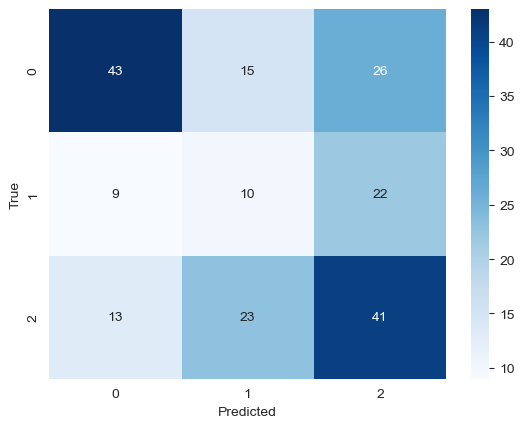

In [116]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [31]:
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.49      0.55      0.52        84
           1       0.28      0.12      0.17        41
           2       0.42      0.49      0.45        77

    accuracy                           0.44       202
   macro avg       0.40      0.39      0.38       202
weighted avg       0.42      0.44      0.42       202

